In [1]:
import sys
from pathlib import Path

# Add the project root and src directory to sys.path 
# This allows both 'from src.module' and internal imports inside src to work
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))
if str(root_path / "src") not in sys.path:
    sys.path.append(str(root_path / "src"))

import pandas as pd
import src.config as config
from src.create_plots import load_csv, create_plot
from src.create_boxplots import create_boxplot

import matplotlib.pyplot as plt
%matplotlib inline

### 1. Identify a Raw File and Display Header Data
We will pick the first available CSV in the `data/raw` folder and print all lines starting with `#`.

In [6]:
target_extension = ["47-"]  # Can be a single string or a list
extensions = [target_extension] if isinstance(target_extension, str) else target_extension

target_files = []
for ext in extensions:
    target_files.extend(config.DATA_RAW.glob(f"*{ext}*.csv"))
target_files = sorted(list(set(target_files)))  # Unique and sorted

if not target_files:
    print(f"No files found in DATA_RAW matching extensions: {extensions}.")
else:
    print(f"Found {len(target_files)} files to analyze.\n")
    for target_file in target_files:
        print(f"--- Metadata for: {target_file.name} ---")
        with open(target_file, 'r') as f:
            for line in f:
                if line.startswith('#'):
                    print(line.strip())
                elif line.strip() == "":
                    continue
                else:
                    break
        print("\n")

Found 5 files to analyze.

--- Metadata for: 260511_0902_47-1_168.csv ---
# \DEVICE          : G 608ST-60802901
# \MODE            : STORED
# DATE             : 11.05.2026
# TIME             : 09:02:12
# Par.Record       :
# Meas. Point No.: : B:47-1
# Outer Diameter  :     168.0 mm
# Wall Thickness  :       5.0 mm
# Roughness       :       0.1 mm
# Pipe Material   : Carbon Steel
# Lining           : WITHOUT LINING
# Medium           : Water
# Medium Temperat.:      20.0 C
# Transducer Type  : CDM1N5213047
# Sound Path       :         2 NUM
# Transd. Distance :      78.2 mm
# Damping          :        10 s
# Full-Scale Val.  :           m3/h
# Current Loop     :           mA
# Storage Rate     :  00:00:01 SAMPLES
# Physic. Quant.   : Volume flow
# Unit Of Measure  : [m3/h]/[m3]
# Numb.Of Meas.Val :       331
# MEASURE Stats -> Avg: 129.8371 | Median: 255.2700 | Mode: 0.0000 | Max: 278.2200 | Min: -260.5800
# SSPEED Stats -> Avg: 1081.3284 | Median: 1499.7000 | Mode: 1501.2000 | Max: 15

### 2. Load Data and Create Trend Plot

Generating trend plot for: MEASURE in 260511_0902_47-1_168.csv


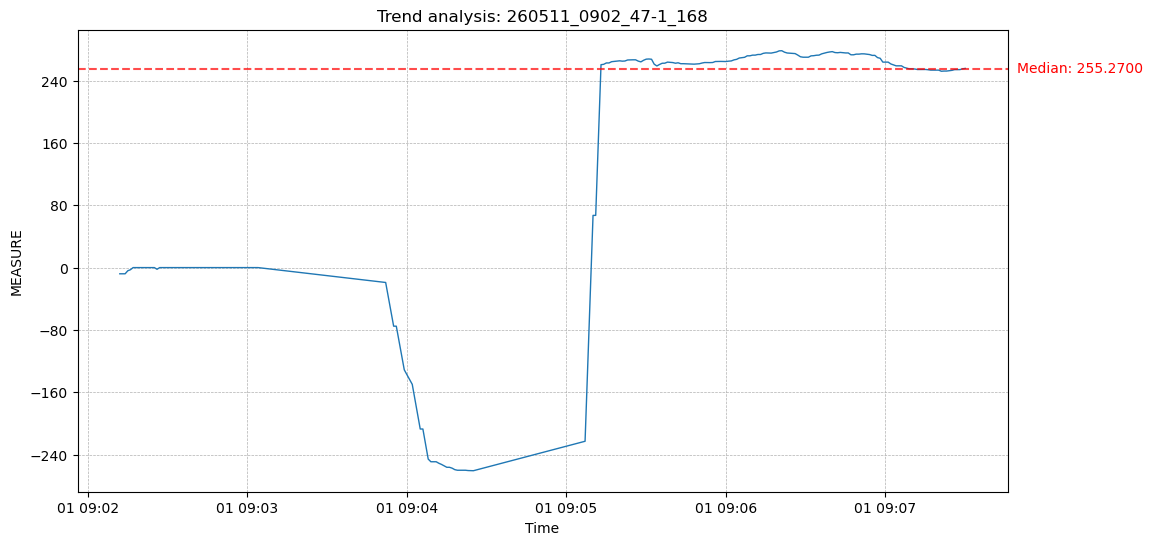

Generating trend plot for: MEASURE in 260511_0911_47-2_220.csv


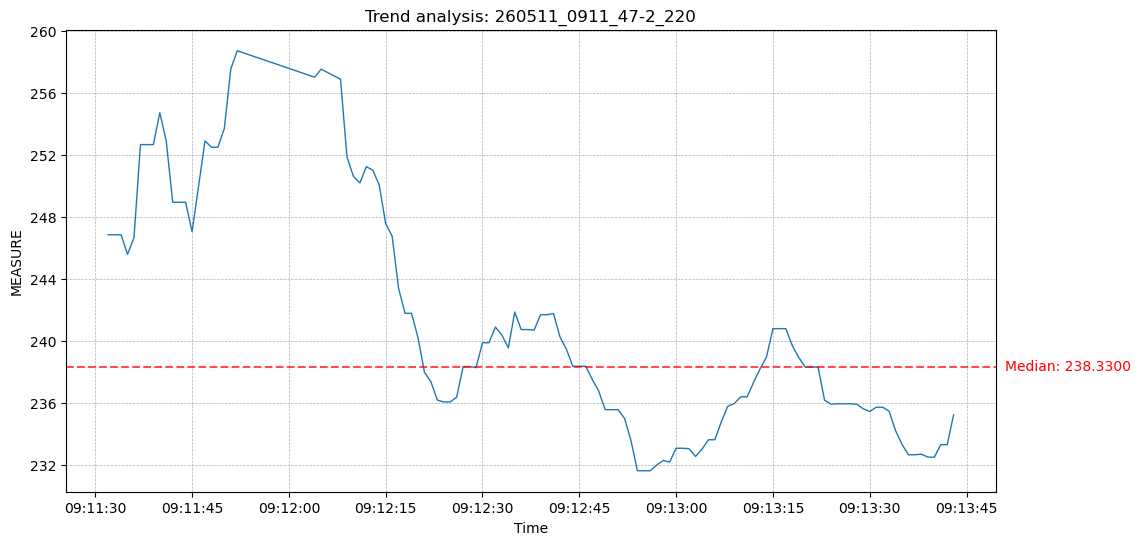

Generating trend plot for: MEASURE in 260511_0916_47-3_220.csv


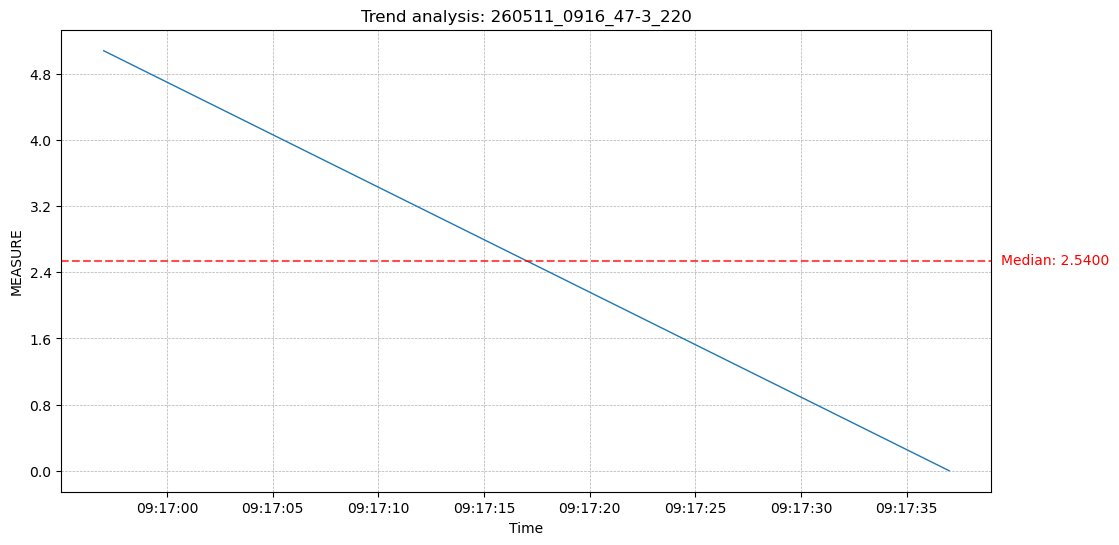

Generating trend plot for: MEASURE in 260511_0918_47-4_220.csv


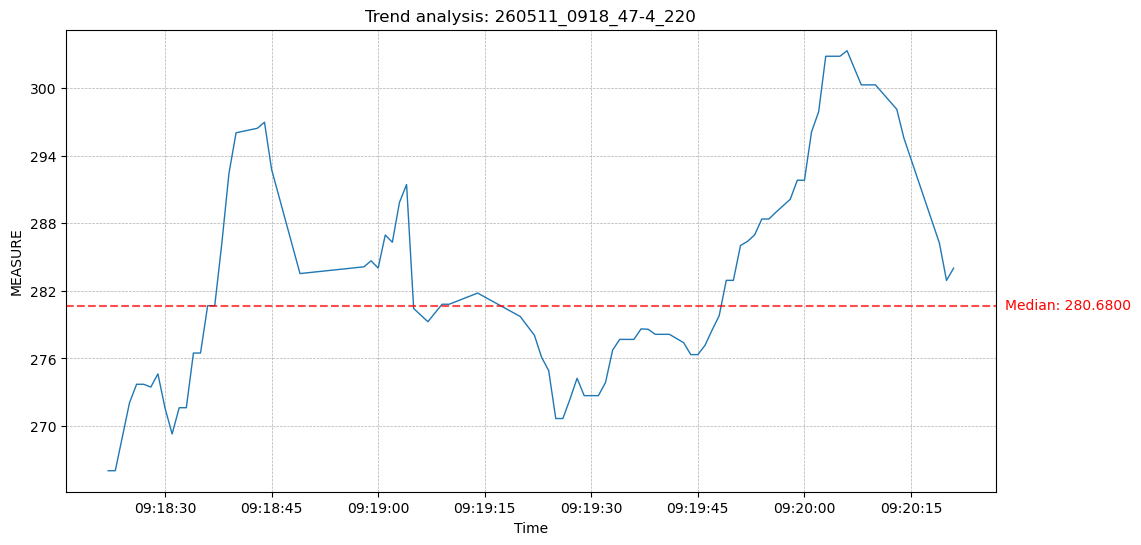

Generating trend plot for: AMP in 260511_0924_47-5_168.csv


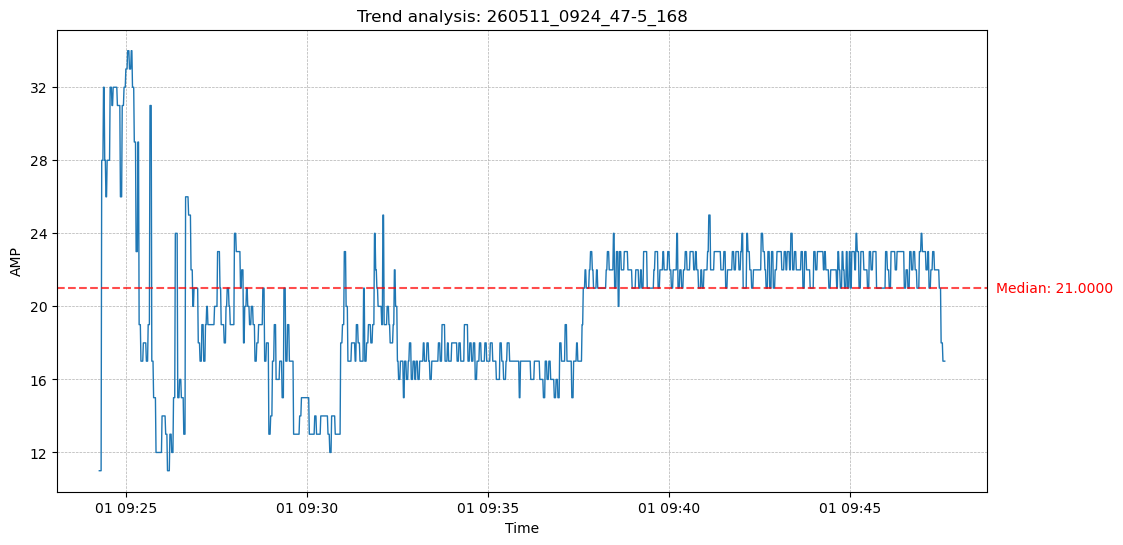

In [ ]:
for target_file in target_files:
    df = load_csv(target_file)
    if df is None: continue

    # Define candidate variables and pick the first one available that is numeric
    candidates = ["MEASURE", "A Flow velocity [m/s]", "SSPEED"]
    variable = next((c for c in candidates if c in df.columns), None)

    # If candidates aren't found or aren't numeric, fallback to any numeric column
    if not variable or pd.to_numeric(df[variable], errors='coerce').dropna().empty:
        numeric_cols = df.select_dtypes(include=['number']).columns
        variable = numeric_cols[0] if not numeric_cols.empty else None

    if variable:
        print(f"Generating trend plot for: {variable} in {target_file.name}")
        fig_trend = create_plot(df, variable, title=f"Trend analysis: {target_file.stem}")
        plt.show()
    else:
        print(f"No numeric variables found to plot in {target_file.name}.")

### 3. Create Boxplot

Generating boxplot for: MEASURE in 260511_0902_47-1_168.csv


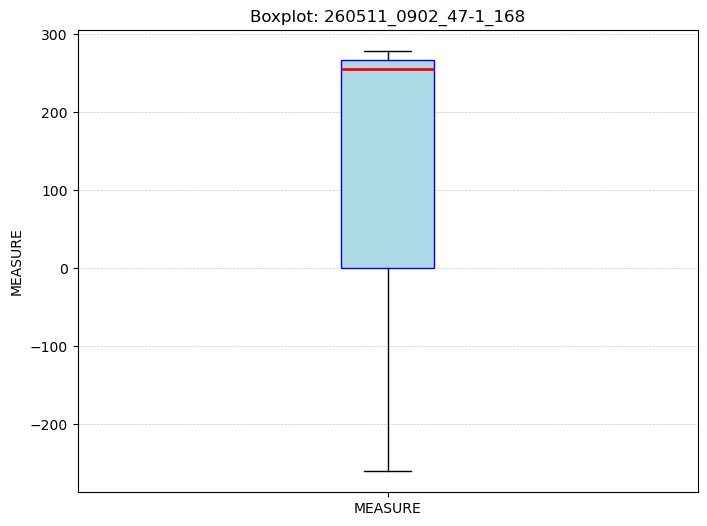

Generating boxplot for: MEASURE in 260511_0911_47-2_220.csv


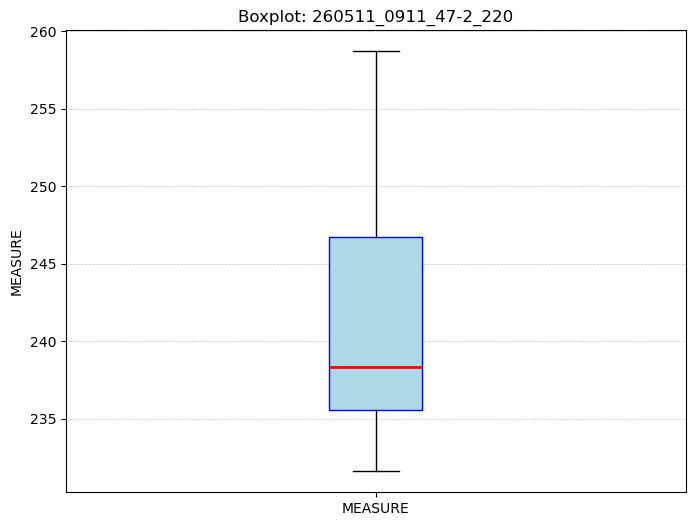

Generating boxplot for: MEASURE in 260511_0916_47-3_220.csv


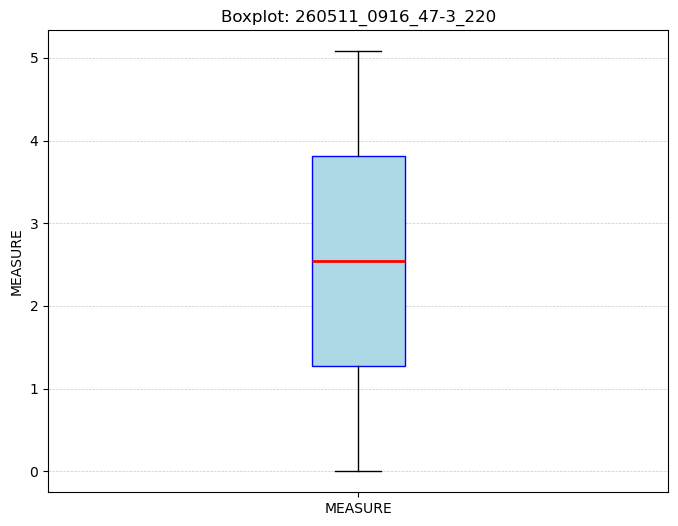

Generating boxplot for: MEASURE in 260511_0918_47-4_220.csv


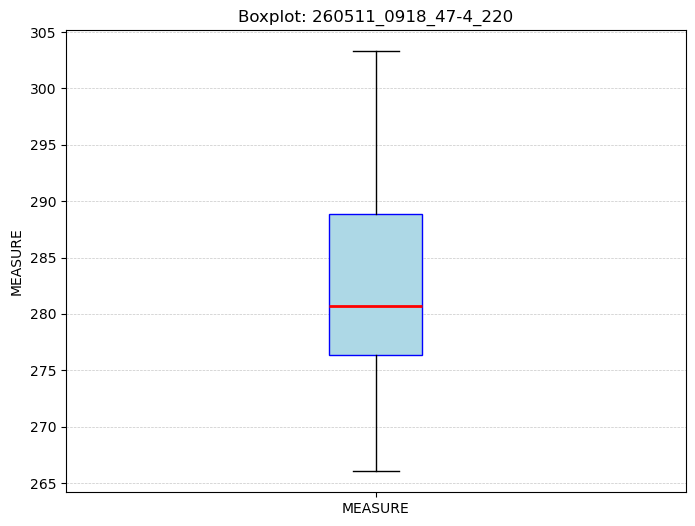

Generating boxplot for: AMP in 260511_0924_47-5_168.csv


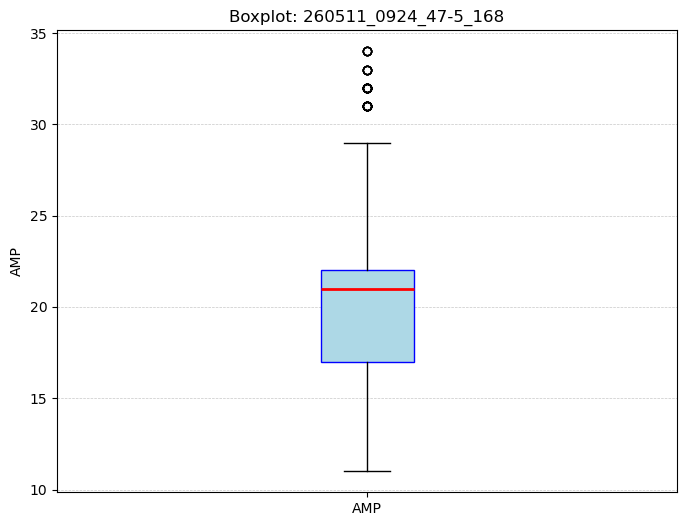

In [8]:
for target_file in target_files:
    df = load_csv(target_file)
    if df is None: continue

    # Detect the best variable for THIS specific file
    candidates = ["MEASURE", "A Flow velocity [m/s]", "SSPEED"]
    variable = next((c for c in candidates if c in df.columns), None)

    if not variable or pd.to_numeric(df[variable], errors='coerce').dropna().empty:
        numeric_cols = df.select_dtypes(include=['number']).columns
        variable = numeric_cols[0] if not numeric_cols.empty else None

    if variable:
        print(f"Generating boxplot for: {variable} in {target_file.name}")
        fig_box = create_boxplot(df, variable, title=f"Boxplot: {target_file.stem}")
        plt.show()
    else:
        print(f"No numeric variables found to plot in {target_file.name}.")